# Oxford-IIIT Pet Transfer Learning with EarlyStopping

ResNet18 pretrained + classification EarlyStopping
목표:
- 기존 baseline 모델에 조기 종료(EarlyStopping) 기능 추가
- 에포크 횟수를 6배 확장(5 -> 30) 시 정확도 변화 관찰
- 핵심 판단: 충분한 학습이 이뤄졌는가? 오히려 과대적합 경향이 나타나는가?


In [13]:
# 2. Environment settings

# 프로젝트에 필요한 라이브러리 및 메서드, 함수, 데이터 세트를 전체 호출하는 셀

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from PIL import Image
from tqdm.auto import tqdm

# 무작위 수행 과정에서 랜덤 시드를 42로 고정(코드 재현성 + 체계성 확보)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# GPU 가능한 환경이라면 GPU 사용하도록 지정(Colab - T4 GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [14]:
# 3. Configuration

# Data & Output & Best-parameters 저장 경로 설정
PROJECT_ROOT = "/content/pet_transfer_project"
DATA_ROOT = os.path.join(PROJECT_ROOT, "data")
OUTPUT_ROOT = os.path.join(PROJECT_ROOT, "outputs")
CKPT_PATH = os.path.join(OUTPUT_ROOT, "best_resnet18_pet.pth")

# 데이터/결과용 폴더 생성
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(OUTPUT_ROOT, exist_ok=True)

# 하이퍼파라미터 설정
BATCH_SIZE = 32
NUM_EPOCHS = 30 # EarlyStopping version에서 변경
LR = 1e-3
WEIGHT_DECAY = 1e-4
VAL_RATIO = 0.2
IMAGE_SIZE = 224
NUM_WORKERS = 2
FREEZE_BACKBONE = True

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("CKPT_PATH:", CKPT_PATH)

PROJECT_ROOT: /content/pet_transfer_project
DATA_ROOT: /content/pet_transfer_project/data
CKPT_PATH: /content/pet_transfer_project/outputs/best_resnet18_pet.pth


In [15]:
# 4. Transform

# 이미지 데이터 전처리를 위한 transform 정의(전처리 + 증강 파이프라인)

# 훈련 데이터용 변환
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop((IMAGE_SIZE, IMAGE_SIZE), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# 평가 및 테스트 데이터용 변환
eval_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [16]:
# 5. DataSet Load & Train-Val-Test Abstraction

# 훈련 데이터 세트 로드(저장 위치, 데이터 종류(trainval) 및 타입(category), 다운로드 여부, 전처리 과정 지정)
full_train_dataset_for_train = OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="category",
    download=True,
    transform=train_tf,
)

# 검증 데이터 세트 로드(저장 위치, 데이터 종류(trainval) 및 타입(category), 다운로드 여부, 전처리 과정 지정)
full_train_dataset_for_eval = OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="category",
    download=False,
    transform=eval_tf,
)

# 테스트 데이터 세트 로드(저장 위치 데이터 종류(test) 및 타입(category), 다운로드 여부, 전처리 과정 지정)
test_dataset = OxfordIIITPet(
    root=DATA_ROOT,
    split="test",
    target_types="category",
    download=False,
    transform=eval_tf,
)

# 타깃 카테고리(품종) 요소 및 개수 저장
class_names = full_train_dataset_for_train.classes
num_classes = len(class_names)

# 전체 데이터 개수로부터 훈련/검증 데이터 개수 추출
# ('Configuration'에서 정의한 검증 비율 VAL_RATIO 사용)
n_total = len(full_train_dataset_for_train)
n_val = int(n_total * VAL_RATIO)
n_train = n_total - n_val

# 훈련-검증 데이터 인덱스 지정(훈련/검증 데이터 개수만큼)
indices = torch.randperm(n_total).tolist()
train_indices = indices[:n_train]
val_indices = indices[n_train:]

# 지정된 인덱스(개수)에 따라 훈련-검증 데이터 세트 분리
# Subset 함수 => 전체 데이터에서 특정 인덱스까지만 접근 가능하게 추출한다.
train_dataset = Subset(full_train_dataset_for_train, train_indices)
val_dataset = Subset(full_train_dataset_for_eval, val_indices)

# 클래스(품종) 개수, 훈련-검증-테스트 크기, 5가지 품종 예시 확인
print("num_classes:", num_classes)
print("train size:", len(train_dataset))
print("val size:", len(val_dataset))
print("test size:", len(test_dataset))
print("first 5 classes:", class_names[:5])

num_classes: 37
train size: 2944
val size: 736
test size: 3669
first 5 classes: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']


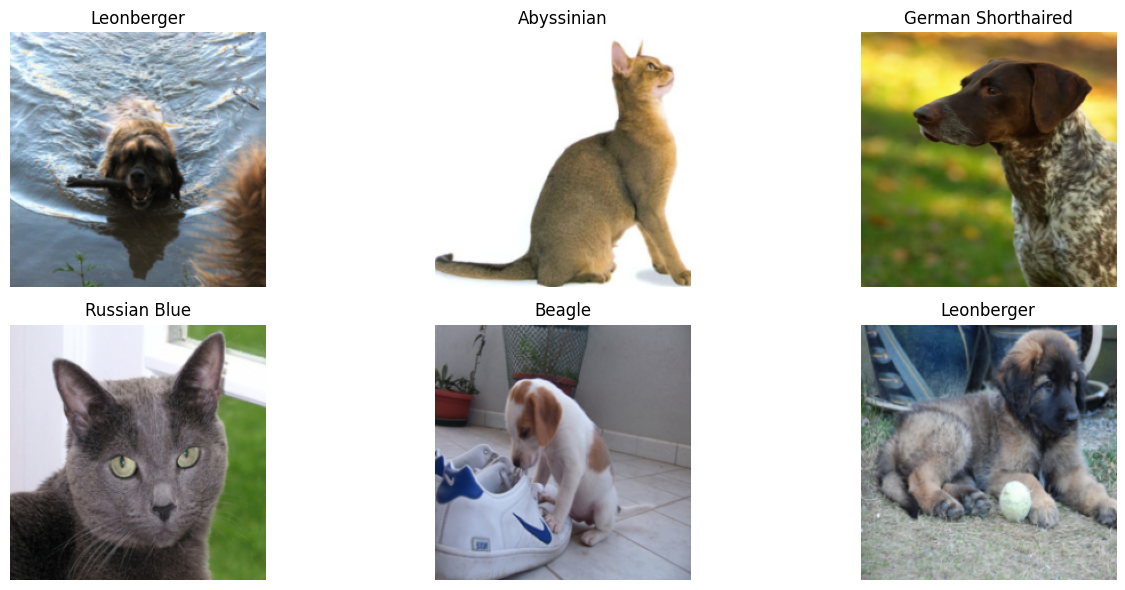

In [17]:
# 6. Definition of functions for checking whether datasets were loaded properly

# 정규화된 이미지를 복원(시각화)하는 함수 정의
def denormalize(x):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (x.cpu() * std + mean).clamp(0, 1)

# 데이터셋의 전반부 6개 샘플을 출력하는 show 함수(복원 함수 기반)
def show_samples(dataset, class_names, n=6):
    plt.figure(figsize=(14, 6))
    for i in range(n):
        image, label = dataset[i]
        image = denormalize(image)
        plt.subplot(2, 3, i + 1)
        plt.imshow(image.permute(1, 2, 0)) # Numpy 데이터처럼 시각화하기 위한 순서 변환
        # image[i].shape [3, 224, 224] -> [224, 224, 3]
        plt.title(class_names[label])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_dataset, class_names, n=6)

In [18]:
# 7. Definition of DataSet_Loader
# DataLoader -“이미지 데이터를 batch로 묶어서 모델에 공급하는 장치”

# train_loader: 과대적합 방지를 위해 shuffle = True로 지정
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

# val_loader: 일관된 검증을 위해 shuffle = False로 지정
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

images, labels = next(iter(train_loader)) # 반복자 객체를 통해 첫번째 배치 꺼내기
print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("example label ids:", labels[:8])

images shape: torch.Size([32, 3, 224, 224])
labels shape: torch.Size([32])
example label ids: tensor([ 0, 35, 28, 20, 34,  4, 21, 32])


In [ ]:
# 8. Creation of Model

# CNN 모델 생성 함수
def build_model(num_classes, freeze_backbone=True):
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        # 전이 학습으로 호출한 모델 파라미터 훈련-변동 (X)

    # CNN 모델 완전 연결층 입력 개수
    in_features = model.fc.in_features

    # CNN 모델 완전 연결층 업데이트: 출력 개수를 num_classses로 변경
    # model(input, output): (512, 1000) -> (512,37)
    model.fc = nn.Linear(in_features, num_classes)
    return model

model = build_model(num_classes=num_classes, freeze_backbone=FREEZE_BACKBONE).to(device)

# freeze_backbone으로 동결되지 않은 -> 훈련 과정에서 업데이트되는 모델 파라미터 개수 체크
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# 모델 파라미터 개수 전체 체크()
total_params = sum(p.numel() for p in model.parameters())

# model.fc -> 완전연결 레이어(Fully Connected)
# mdoel.fc의 두 가지 기능: 1. 완전 연결 & 2. 최종 분류기(예측 출력 레이어)
print("model.fc:", model.fc)
print("trainable params:", trainable_params)
print("total params:", total_params)
print(f"Trainable ratio: {100 * trainable_params / total_params:.2f}%")

model.fc: Linear(in_features=512, out_features=37, bias=True)
trainable params: 18981
total params: 11195493
Trainable ratio: 0.17%


In [ ]:
# 9-1. Definitions of Train/Evaluation Function

criterion = nn.CrossEntropyLoss()

if FREEZE_BACKBONE:
  # freeze_backbone(모델 파라미터 동결)을 적용하는 경우, 완전 연결층에만 옵티마이저 적용
    optimizer = optim.Adam(model.fc.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
else:
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def train_one_epoch(model, loader, criterion, optimizer, device):

    #  에포크가 '훈련' 과정에 속함을 명시적으로 표현
    model.train()

    # 에포크마다 훈련 손실 및 정확도 초기화
    running_loss = 0.0
    running_correct = 0

    # 이미지(레이블) 미니 배치마다 훈련 반복
    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        # 훈련마다 그레이언트(기울기) 초기화
        optimizer.zero_grad()
        # 모델에 이미지 입력 -> 순전파(forward pass) 실행 -> 결과 예측
        logits = model(images)
        # 예측한 결과와 실제 정답 간 오차 산출
        loss = criterion(logits, labels)
        # 오차 역전파
        loss.backward()
        # 오차를 반영한 가중치 업데이트
        optimizer.step()

        # 전체 평균 손실 합산을 위한 '미니배치' 손실 계산(미니배치 손실 크기 * 배치 사이즈)
        running_loss += loss.item() * images.size(0)
        # 가장 확률 높은 예측 클래스 저장
        preds = logits.argmax(dim=1)
        # 가장 확률 높은 예측 클래스와 실제 정답이 일치하는 비율을 정확도로 산출
        running_correct += (preds == labels).sum().item()

    # 평균 에포크 손실 = 전체 에포크 손실 / 전체 데이터 크기
    # 평균 에포크 정확도 = 전체 에포크 정확도 / 전체 데이터 크기
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    return epoch_loss, epoch_acc

@torch.no_grad() # 평가 함수에서 불필요한 gradient 계산 생략 -> 속도 향상
def evaluate(model, loader, criterion, device):

    # #  에포크가 '평가' 과정에 속함을 명시적으로 표현
    model.eval()
    running_loss = 0.0
    running_correct = 0


    # 모델 파라미터 업데이트 유무를 제외하면 훈련 함수와 매우 유사
    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

    # 타깃 예측 & 손실 측정 & 정확도 산출 수행
        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    return epoch_loss, epoch_acc

In [21]:
# 9-2. Definitions of EarlyStopping Function

class EarlyStopping:
    # 설정된 patience 이후로 validation loss가 개선되지 않으면 학습을 조기 종료
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt'):


            # patience (int): 개선되지 않는 에포크 수 (How many epochs to wait before stopping)
            # verbose (bool): 모든 에포크마다 개선 정보 표시(True) VS 최종(조기종료 시점) 에포크 정보만 표시(False)
            # delta (float): 개선으로 간주하기 위한 최소 변화량 (Minimum change in the monitored quantity)
            # path (str): 체크포인트 저장 경로

        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        # validation loss가 감소하면 모델을 저장
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [22]:
import numpy as np

# 10. Run Model's Train


class EarlyStopping:
    # 설정된 patience 이후로 validation loss가 개선되지 않으면 학습을 조기 종료
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        # validation loss가 감소하면 모델을 저장
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = 0.0

early_stopping = EarlyStopping(patience=5, verbose=True)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"[Epoch {epoch+1}/{NUM_EPOCHS}] "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        # 검증 정확도 > 이전 최고 기록 -> 해당 모델을 저장
        # 저장 대상은 state_dict(모델 파라미터 대상)
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "val_acc": best_val_acc,
        }, CKPT_PATH)
        print(f"Best model saved to: {CKPT_PATH}")

    early_stopping(val_loss, model)

    # 조기 종료 조건 확인
    if early_stopping.early_stop:
        print("Early stopping")
        break

print("best_val_acc:", best_val_acc)

  0%|          | 0/92 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x793bf6a88cc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x793bf6a88cc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[Epoch 1/30] train_loss=2.1494, train_acc=0.5058, val_loss=1.0354, val_acc=0.8043
Best model saved to: /content/pet_transfer_project/outputs/best_resnet18_pet.pth
Validation loss decreased (inf --> 1.035369).  Saving model ...


  0%|          | 0/92 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

[Epoch 21/30] train_loss=0.1193, train_acc=0.9721, val_loss=0.3223, val_acc=0.8886
EarlyStopping counter: 4 out of 5


  0%|          | 0/92 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

[Epoch 22/30] train_loss=0.1090, train_acc=0.9806, val_loss=0.3022, val_acc=0.9022
EarlyStopping counter: 5 out of 5
Early stopping
best_val_acc: 0.904891304347826


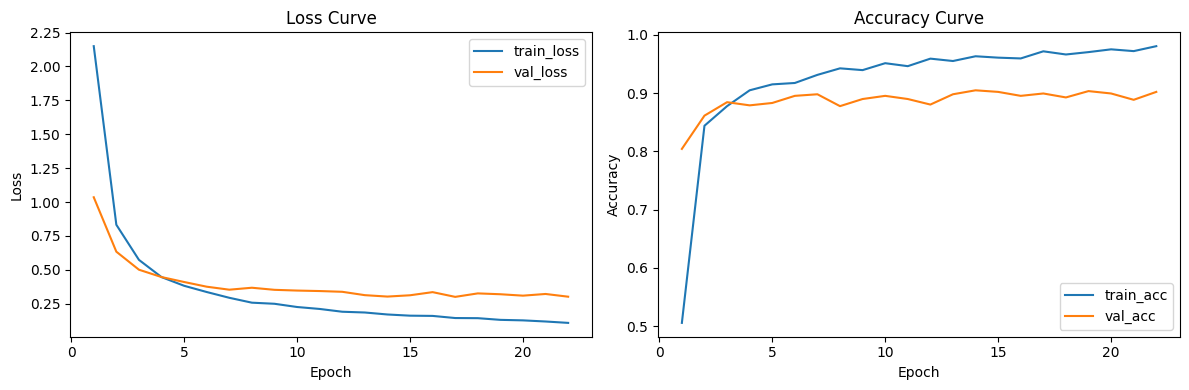

In [23]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train_acc")
plt.plot(epochs, history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.tight_layout()
plt.show()

In [24]:
# 12. Final Test

# 최적의 모델 파라미터를 적용하기 위한, 같은 구조의 모델 생성
best_model = build_model(num_classes=num_classes, freeze_backbone=FREEZE_BACKBONE).to(device)

# map_location=device -> device에 맞춰 저장된 checkpoint 파일 호출
ckpt = torch.load(CKPT_PATH, map_location=device)
# checkpoint 파일에 저장된 최적 모델 파라미터 -> 모델에 적용
best_model.load_state_dict(ckpt["model_state_dict"])

# 평가 함수 실행 & 최종 정확도 산출
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

  0%|          | 0/115 [00:00<?, ?it/s]

test_loss=0.3948, test_acc=0.8784


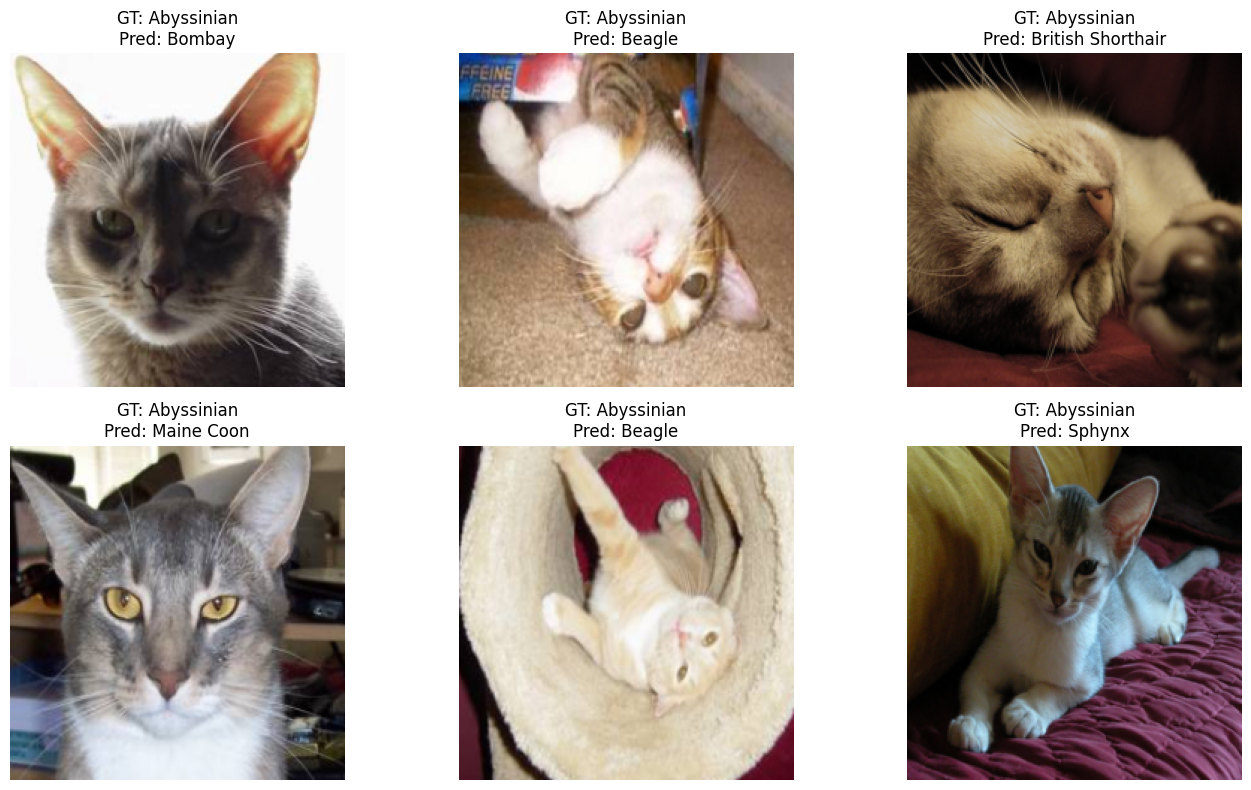

In [25]:
# 13. Reveiwing Predict results & Wrong answer Samples

@torch.no_grad() # 훈련 평가/추론 단계 -> gradeint 계산 생략

# 오답 샘플을 모으는 함수(최대 6개까지)
def collect_wrong_predictions(model, loader, class_names, max_items=6):
    model.eval()
    wrong_items = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # 모델 예측 수행 & 데이터별 가장 높은 점수 클래스 1개 고르기
        logits = model(images)
        preds = logits.argmax(dim=1)

        # 예측 클래스와 실제 라벨이 다르다 -> 오답 판별
        wrong_mask = preds != labels
        wrong_indices = wrong_mask.nonzero(as_tuple=True)[0]

        # 오답 샘플 이미지 & 실제 라벨(클래스) & 예측 라벨 출력
        for idx in wrong_indices:
            wrong_items.append({
                "image": images[idx].cpu(),
                "true_label": class_names[labels[idx].item()],
                "pred_label": class_names[preds[idx].item()],
            })
            if len(wrong_items) >= max_items:
                return wrong_items
    return wrong_items

wrong_items = collect_wrong_predictions(best_model, test_loader, class_names, max_items=6)

plt.figure(figsize=(14, 8))
for i, item in enumerate(wrong_items):
    image = denormalize(item["image"])
    plt.subplot(2, 3, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"GT: {item['true_label']}\nPred: {item['pred_label']}")
    plt.axis("off")
plt.tight_layout()
plt.show()

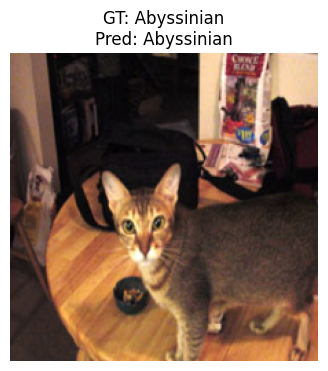

In [26]:
# Inferring single-samples
# 훈련-평가 단계에서는 배치(batch) 단위 데이터 입력 & 처리
# 해당 단계에서는 이미지 한 장만을 골라 예측 결과 확인(단일 샘플)


@torch.no_grad()
def predict_one_from_dataset(model, dataset, idx=0):
    model.eval()
    image, label = dataset[idx]
    # 샘플 크기 맨 앞에 batch 차원 추가 [3, 224, 224] -> [1, 3, 224, 224]
    x = image.unsqueeze(0).to(device)

    logits = model(x)
    pred = logits.argmax(dim=1).item()

    plt.figure(figsize=(4, 4))
    plt.imshow(denormalize(image).permute(1, 2, 0))
    plt.title(f"GT: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

predict_one_from_dataset(best_model, test_dataset, idx=0)